# Análisis Exploratorio de Datos

**Caso de Estudio:** Ecommerce Customer Dataset
**Asignatura:** MLY1101 — Machine Learning
**Laboratorio de Modelamiento Supervisado: Regresión y Clasificación**

---

## Descripción

Este notebook corresponde a la **Fase 2 (Comprensión de los datos)** de la metodología CRISP-DM
aplicada al caso de estudio Ecommerce Customer Dataset: 10.000 clientes con sus datos
demográficos (país, género, edad), su relación con la empresa (antigüedad, saldo, productos
contratados, actividad) y una marca de si el cliente abandonó la empresa (Exited).

El objetivo no es solo describir los datos, sino **encontrar hallazgos (insights)** que respondan
dos preguntas de negocio y orienten el modelado supervisado:

- **¿Qué clientes abandonan la empresa?** → target de clasificación: Exited.
- **¿De qué depende el saldo de un cliente?** → target de regresión: Balance.

El notebook sigue este orden:

1. Carga de los datos.
2. Auditoría de calidad: cada columna se revisa con una pregunta concreta, y cada patrón
   llamativo se pone a prueba antes de aceptarlo como real.
3. Descripción de las variables y sus relaciones.
4. Hallazgos sobre el abandono (clasificación).
5. Hallazgos sobre el saldo (regresión).
6. Resumen de hallazgos y sus implicancias para la preparación de datos.

Cada gráfico lleva como título su hallazgo principal, y se guarda en `images/`.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. Bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (>=3.7.1)
- numpy (>=2.0.0)

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
```

# Importación de librerías

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('bmh')

os.makedirs('../images', exist_ok=True)

# 1. Carga de datos

In [34]:
df = pd.read_csv('../data/ecommerce_customer_data.csv')
df.sample(5, random_state=42)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6252,6253,15687492,Anderson,596,Germany,Male,32,3,96709.07,2,0,0,41788.37,0
4684,4685,15736963,Herring,623,France,Male,43,1,0.00,2,1,1,146379.30,0
1731,1732,15721730,Amechi,601,Spain,Female,44,4,0.00,2,1,0,58561.31,0
4742,4743,15762134,Liang,506,Germany,Male,59,8,119152.10,2,1,1,170679.74,0
4521,4522,15648898,Chuang,560,Spain,Female,27,7,124995.98,1,1,1,114669.79,0


RowNumber es solo el número de fila del archivo original (1 a 10.000), no aporta información
sobre el cliente, por lo que se descarta.

In [35]:
df = df.iloc[:, 1:]
df.sample(5, random_state=42)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6252,15687492,Anderson,596,Germany,Male,32,3,96709.07,2,0,0,41788.37,0
4684,15736963,Herring,623,France,Male,43,1,0.00,2,1,1,146379.30,0
1731,15721730,Amechi,601,Spain,Female,44,4,0.00,2,1,0,58561.31,0
4742,15762134,Liang,506,Germany,Male,59,8,119152.10,2,1,1,170679.74,0
4521,15648898,Chuang,560,Spain,Female,27,7,124995.98,1,1,1,114669.79,0


# 2. Calidad de los datos

Antes de sacar cualquier conclusión se audita el dataset: tamaño, duplicados, nulos, tipos,
rangos válidos y valores atípicos. Además, cada patrón que parezca demasiado llamativo para ser
natural se pone a prueba, para distinguir un comportamiento real de los clientes de un efecto
de cómo se armó la muestra (por ejemplo, que los clientes de un país se hayan elegido con un
criterio distinto al del resto).

## 2.1 ¿Cuántas columnas y filas contiene el dataset?

In [36]:
filas, columnas = df.shape
print(f'Filas = {filas}\nColumnas = {columnas}')

Filas = 10000
Columnas = 13


## 2.2 ¿Existen filas duplicadas?

In [37]:
# Duplicados exactos: filas idénticas en todas las columnas
duplicados_exactos = df.duplicated().sum()
print(f'Filas totalmente duplicadas: {duplicados_exactos}')

# Duplicados por CustomerId: un mismo cliente no debería aparecer dos veces
duplicados_cliente = df.duplicated(subset='CustomerId').sum()
print(f'Clientes repetidos (mismo CustomerId): {duplicados_cliente}')

Filas totalmente duplicadas: 0
Clientes repetidos (mismo CustomerId): 0


No hay filas duplicadas ni clientes repetidos: cada fila es un cliente único, no se requiere
ninguna consolidación.

## 2.3 ¿Existen valores nulos?

In [38]:
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Ninguna columna tiene valores nulos.

## 2.4 ¿Los tipos de datos son consistentes con el contenido real de cada columna?

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


Los tipos son consistentes, con un matiz: HasCrCard, IsActiveMember y Exited están guardadas
como int64, pero son **binarias** (0/1), no cantidades. Se analizan aparte de las numéricas
continuas. NumOfProducts también es int64, pero solo toma 4 valores; en la Sección 4.2 se ve
que conviene tratarla como categórica.

## 2.5 ¿Los valores respetan un rango válido?

In [40]:
# Rango válido esperado para cada columna numérica (mínimo, máximo)
rangos_validos = {
    'CreditScore':     (300, 850),       # escala estándar de puntaje crediticio
    'Age':             (18, 100),        # clientes adultos
    'Tenure':          (0, 10),          # años como cliente
    'Balance':         (0, np.inf),      # el saldo no puede ser negativo
    'NumOfProducts':   (1, 4),           # productos contratados
    'EstimatedSalary': (0, np.inf),
}

filas_resumen = []
for columna, (minimo, maximo) in rangos_validos.items():
    serie = df[columna]
    filas_resumen.append({
        'columna': columna,
        'rango_valido': f'[{minimo}, {maximo}]',
        'minimo_real': serie.min(),
        'maximo_real': serie.max(),
        'total_inconsistentes': ((serie < minimo) | (serie > maximo)).sum(),
    })

pd.DataFrame(filas_resumen)

,columna,rango_valido,minimo_real,maximo_real,total_inconsistentes
0,CreditScore,"[300, 850]",350.00,850.00,0
1,Age,"[18, 100]",18.00,92.00,0
2,Tenure,"[0, 10]",0.00,10.00,0
3,Balance,"[0, inf]",0.00,250898.09,0
4,NumOfProducts,"[1, 4]",1.00,4.00,0
5,EstimatedSalary,"[0, inf]",11.58,199992.48,0


In [41]:
print(f"Clientes con CreditScore = 850: {(df['CreditScore'] == 850).sum()}")
print(f"Clientes con EstimatedSalary < 1.000: {(df['EstimatedSalary'] < 1000).sum()}")

Clientes con CreditScore = 850: 233
Clientes con EstimatedSalary < 1.000: 59


No hay valores fuera de rango. Dos casos llaman la atención pero no son errores:

- **CreditScore = 850** (el techo de la escala) concentra 233 clientes: es el efecto de un
  puntaje acotado, no un error de carga.
- **EstimatedSalary** tiene 59 clientes con menos de 1.000 al año (mínimo 11,58). Es muy bajo,
  pero al ser una *estimación* y no un dato declarado no hay base para considerarlo un error.

## 2.6 ¿Existen valores atípicos?

Se aplica la regla estándar de rango intercuartílico (IQR): un valor es atípico si cae fuera
de [Q1 − 1,5·IQR, Q3 + 1,5·IQR].

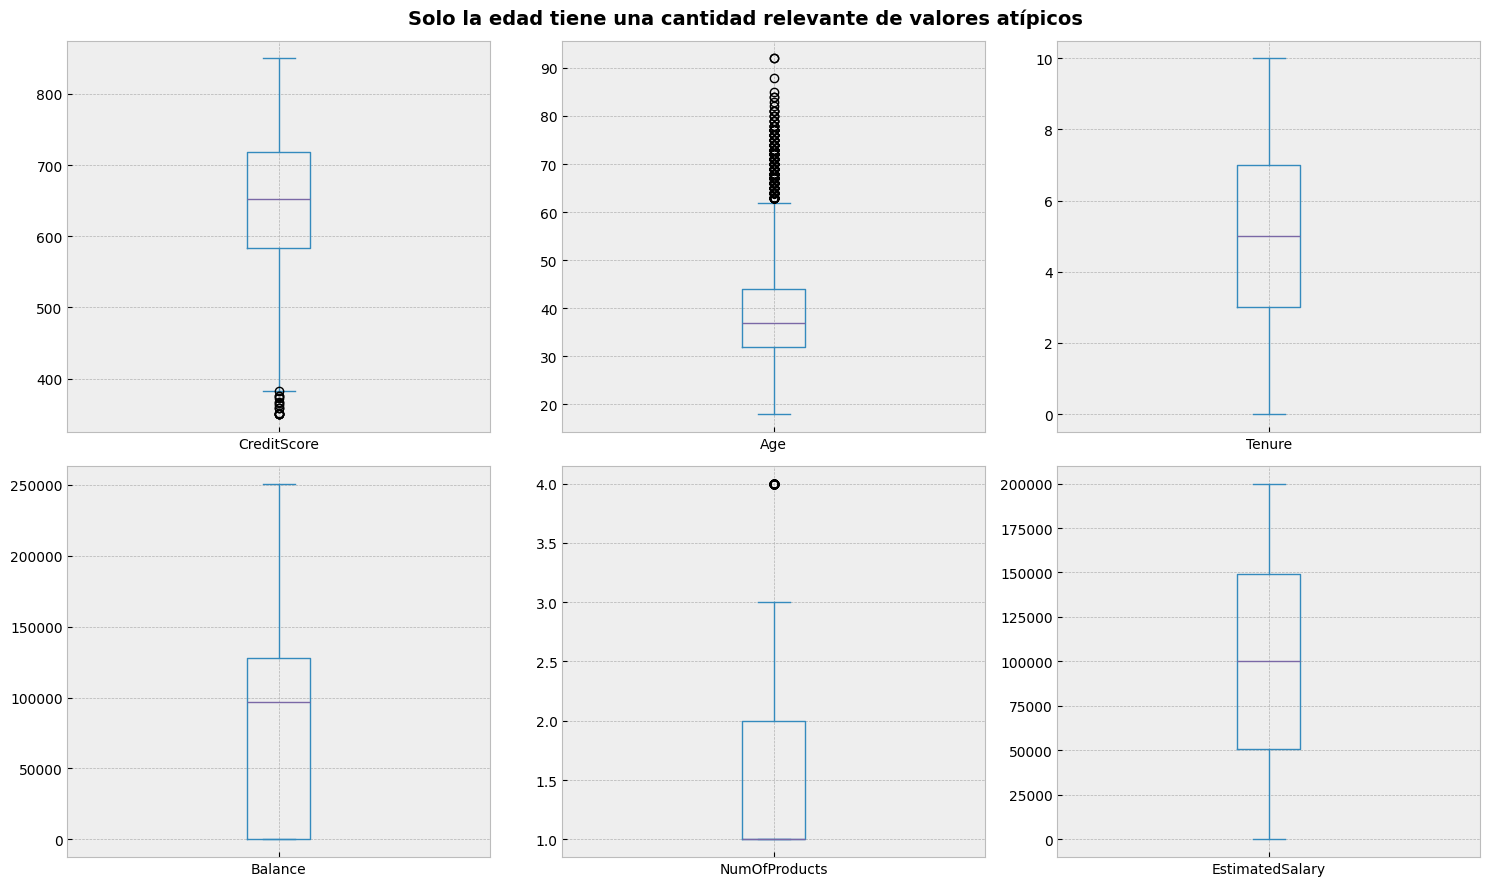

In [42]:
columnas_numericas = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

df[columnas_numericas].plot(kind='box', subplots=True, layout=(2, 3), figsize=(15, 9), sharex=False, sharey=False)
plt.suptitle('Solo la edad tiene una cantidad relevante de valores atípicos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/boxplot_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# Porcentaje de outliers según la regla IQR
print(f"{'columna':18s} {'% abajo':>9s} {'% arriba':>9s}")
for col in columnas_numericas:
    q1, q3 = df[col].quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    print(f"{col:18s} {(df[col] < lo).mean()*100:8.2f}% {(df[col] > hi).mean()*100:8.2f}%")

columna              % abajo  % arriba
CreditScore            0.15%     0.00%
Age                    0.00%     3.59%
Tenure                 0.00%     0.00%
Balance                0.00%     0.00%
NumOfProducts          0.00%     0.60%
EstimatedSalary        0.00%     0.00%


- **Age:** 3,59% de atípicos hacia arriba (clientes sobre ~62 años, hasta 92). Son edades
  reales, y como se verá en la Sección 4.3 son **informativas**: el abandono cambia bruscamente
  en los mayores de 60. Por eso **no se recortan**.
- **CreditScore:** 0,15% hacia abajo (puntajes bajo ~383), valores válidos de la escala.
- **NumOfProducts:** los 60 clientes con 4 productos (0,6%) aparecen como atípicos, pero es una
  categoría poco frecuente, no un valor extremo.
- Tenure, Balance y EstimatedSalary no tienen atípicos.

## 2.7 ¿Es confiable la distribución del saldo por país?

Al cruzar Balance con Geography aparece un patrón demasiado limpio para ser natural, así que se
investiga antes de aceptarlo.

In [44]:
saldo_por_pais = df.groupby('Geography')['Balance'].agg(
    clientes='size',
    clientes_saldo_cero=lambda s: (s == 0).sum(),
    pct_saldo_cero=lambda s: (s == 0).mean() * 100,
    saldo_minimo='min',
    saldo_medio='mean',
    saldo_medio_si_tiene_saldo=lambda s: s[s > 0].mean(),
)
saldo_por_pais.round(1)

,clientes,clientes_saldo_cero,pct_saldo_cero,saldo_minimo,saldo_medio,saldo_medio_si_tiene_saldo
Geography,,,,,,
France,5014,2418,48.2,0.0,62092.6,119927.8
Germany,2509,0,0.0,27288.4,119730.1,119730.1
Spain,2477,1199,48.4,0.0,61818.1,119815.0


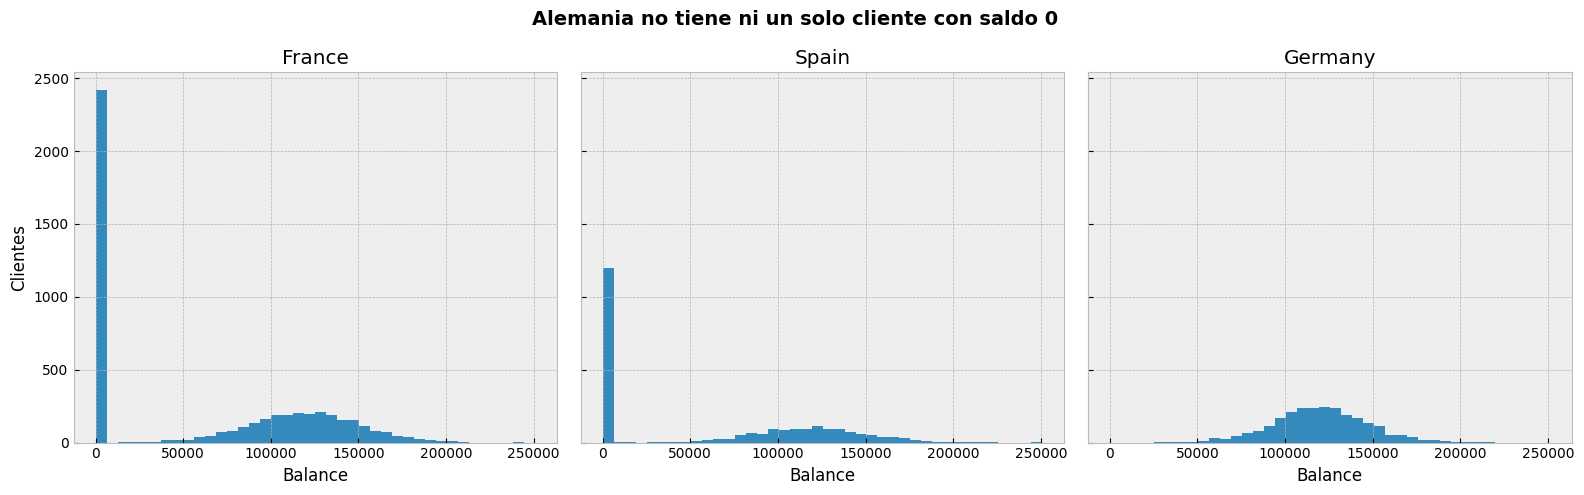

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
bins = np.linspace(0, df['Balance'].max(), 41)   # mismos tramos en los tres países
for ax, pais in zip(axes, ['France', 'Spain', 'Germany']):
    df.loc[df['Geography'] == pais, 'Balance'].hist(bins=bins, ax=ax)
    ax.set_title(pais)
    ax.set_xlabel('Balance')
axes[0].set_ylabel('Clientes')
plt.suptitle('Alemania no tiene ni un solo cliente con saldo 0', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/saldo_por_pais.png', dpi=150, bbox_inches='tight')
plt.show()

En Francia y España ~48% de los clientes tiene saldo 0 (la barra alta a la izquierda). En
Alemania, ninguno: su saldo mínimo es 27.288. Sin embargo, los clientes alemanes **no tienen más
dinero**: entre quienes tienen saldo, el promedio es el mismo en los tres países (~120.000). En
una población real de 2.509 clientes sería muy improbable que ninguno tuviera saldo 0.

La explicación más plausible es un **sesgo de selección** en la construcción del dataset (por
ejemplo, que de Alemania solo se hayan incluido clientes con saldo). No se puede confirmar sin
conocer el origen de los datos, pero tiene consecuencias directas:

- Cualquier relación entre ser de Alemania y tener más saldo (Sección 3.3) probablemente se
  debe a cómo se armó la muestra, no a un comportamiento de los clientes.
- Un modelo de regresión aprenderá la regla "alemán = tiene saldo", que podría fallar con
  clientes reales. Su efecto se mide en [`modelamiento.ipynb`](modelamiento.ipynb).
- No se puede corregir eliminando filas: se conserva y se documenta como limitación.

## 2.8 ¿El mayor abandono de Alemania también se debe a cómo se armó la muestra?

Alemania también abandona más (32,4% contra ~16,5% de Francia y España). Si ese efecto viniera
solo de que sus clientes son distintos en otra variable (más edad, menos actividad, más saldo),
no sería un efecto del país. Se comparan clientes parecidos:

In [46]:
print(df.groupby('Geography')[['Age', 'IsActiveMember', 'CreditScore', 'Tenure']].mean().round(2), '\n')

pais = pd.Series(np.where(df['Geography'] == 'Germany', 'Alemania', 'Francia/España'), index=df.index)

# Cada variable separa a los clientes en grupos parecidos; dentro de cada grupo se compara
# el abandono de Alemania con el de Francia/España
variables_control = {
    'Productos': df['NumOfProducts'].map({1: '1', 2: '2', 3: '3 o 4', 4: '3 o 4'}),
    'Actividad': df['IsActiveMember'].map({1: 'Activo', 0: 'Inactivo'}),
    'Edad':      pd.cut(df['Age'], bins=[17, 40, 60, 100], labels=['18-40', '41-60', 'Más de 60']),
    'Saldo':     pd.Series(np.where(df['Balance'] > 0, 'Con saldo', 'Saldo 0'), index=df.index),
}

abandono_por_variable = {}
for nombre, grupos in variables_control.items():
    tabla = df.groupby([grupos, pais], observed=True)['Exited'].mean().unstack() * 100
    tabla['veces'] = tabla['Alemania'] / tabla['Francia/España']
    clientes = df.groupby([grupos, pais], observed=True).size().unstack()
    tabla['clientes_Alemania'] = clientes['Alemania']
    tabla['clientes_Francia/España'] = clientes['Francia/España']
    abandono_por_variable[nombre] = tabla

pd.concat(abandono_por_variable).round(2)

             Age  IsActiveMember  CreditScore  Tenure
Geography                                            
France     38.51            0.52       649.67    5.00
Germany    39.77            0.50       651.45    5.01
Spain      38.89            0.53       651.33    5.03 



Alemania  Francia/España  veces  clientes_Alemania  \
Productos 1             42.85           22.25   1.93             1349.0   
          2             12.12            6.25   1.94             1040.0   
          3 o 4         91.67           82.52   1.11              120.0   
Actividad Activo        23.72           11.25   2.11             1248.0   
          Inactivo      41.08           21.85   1.88             1261.0   
Edad      18-40         18.31            8.41   2.18             1475.0   
          41-60         54.29           33.52   1.62              921.0   
          Más de 60     38.94           20.23   1.92              113.0   
Saldo     Con saldo     32.44           18.66   1.74             2509.0   
          Saldo 0         NaN           13.82    NaN                NaN   

                     clientes_Francia/España  
Productos 1                           3735.0  
          2                           3550.0  
          3 o 4                        206.0  
Actividad Activo                      3903.0  
          Inactivo                    3588.0  
Edad      18-40                       4944.0  
          41-60                       2196.0  
          Más de 60                    351.0  
Saldo     Con saldo                   3874.0  
          Saldo 0                     3617.0

Los clientes alemanes tienen la misma edad, actividad, puntaje y antigüedad promedio que los
de Francia y España, y aun así **abandonan más dentro de cada grupo**: entre 1,6 y 2,2 veces
más en casi todos. La excepción son los clientes con 3 o 4 productos, donde casi todos abandonan
en ambos grupos (91,7% vs. 82,5%, apenas 1,1 veces más): cuando el abandono ya está cerca del
100%, no hay espacio para que se duplique.

En la variable Saldo, Alemania no tiene fila "Saldo 0" (queda vacía) porque ningún alemán tiene
saldo 0. Entre los clientes con saldo, Alemania igual abandona 1,74 veces más, lo que descarta
que la diferencia venga solo del saldo.

A diferencia del saldo, este efecto no desaparece al comparar clientes parecidos, por lo que
para los modelos es una señal propia del país.

Si es un comportamiento real (competencia, condiciones del mercado) o también parte del sesgo de
selección de la Sección 2.7, no se puede saber con estos datos. Se usa como predictor, dejando
documentada la duda. El gráfico está en la Sección 4.5.

## 2.9 Conclusiones de la auditoría de calidad

- Se descartó RowNumber (número de fila). CustomerId y Surname se mantienen en este análisis
  solo como referencia: son identificadores del cliente, sin valor predictivo y datos personales.
- No hay que eliminar ninguna fila: no hay duplicados, nulos ni valores fuera de rango.
- Los valores atípicos son reales (Sección 2.6), y los de Age son informativos.
- El patrón de saldo de Alemania es un probable sesgo de selección (Sección 2.7): no se puede
  corregir con estos datos, solo documentar y tener en cuenta al interpretar los resultados.
- HasCrCard, IsActiveMember y Exited son binarias, no numéricas.

# 3. Descripción de las variables

Para el análisis descriptivo se separan las columnas que no son atributos continuos: Exited
(el target de clasificación, se analiza en la Sección 4), CustomerId y Surname
(identificadores) y las binarias HasCrCard e IsActiveMember.

In [47]:
df2 = df.drop(columns=['Exited', 'CustomerId', 'HasCrCard', 'IsActiveMember', 'Surname'])
df2.sample(5, random_state=42)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
6252,596,Germany,Male,32,3,96709.07,2,41788.37
4684,623,France,Male,43,1,0.00,2,146379.30
1731,601,Spain,Female,44,4,0.00,2,58561.31
4742,506,Germany,Male,59,8,119152.10,2,170679.74
4521,560,Spain,Female,27,7,124995.98,1,114669.79


## 3.1 Variables numéricas

Separaremos las columnas numéricas para un correcto análisis

In [48]:
numerical_cols = df2[df2.columns[(df2.dtypes == 'float64') | (df2.dtypes == 'int64')]]
numerical_cols.sample(5, random_state=42)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
6252,596,32,3,96709.07,2,41788.37
4684,623,43,1,0.00,2,146379.30
1731,601,44,4,0.00,2,58561.31
4742,506,59,8,119152.10,2,170679.74
4521,560,27,7,124995.98,1,114669.79


In [49]:
numerical_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Age              10000 non-null  int64  
 2   Tenure           10000 non-null  int64  
 3   Balance          10000 non-null  float64
 4   NumOfProducts    10000 non-null  int64  
 5   EstimatedSalary  10000 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 468.9 KB


In [50]:
numerical_cols.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


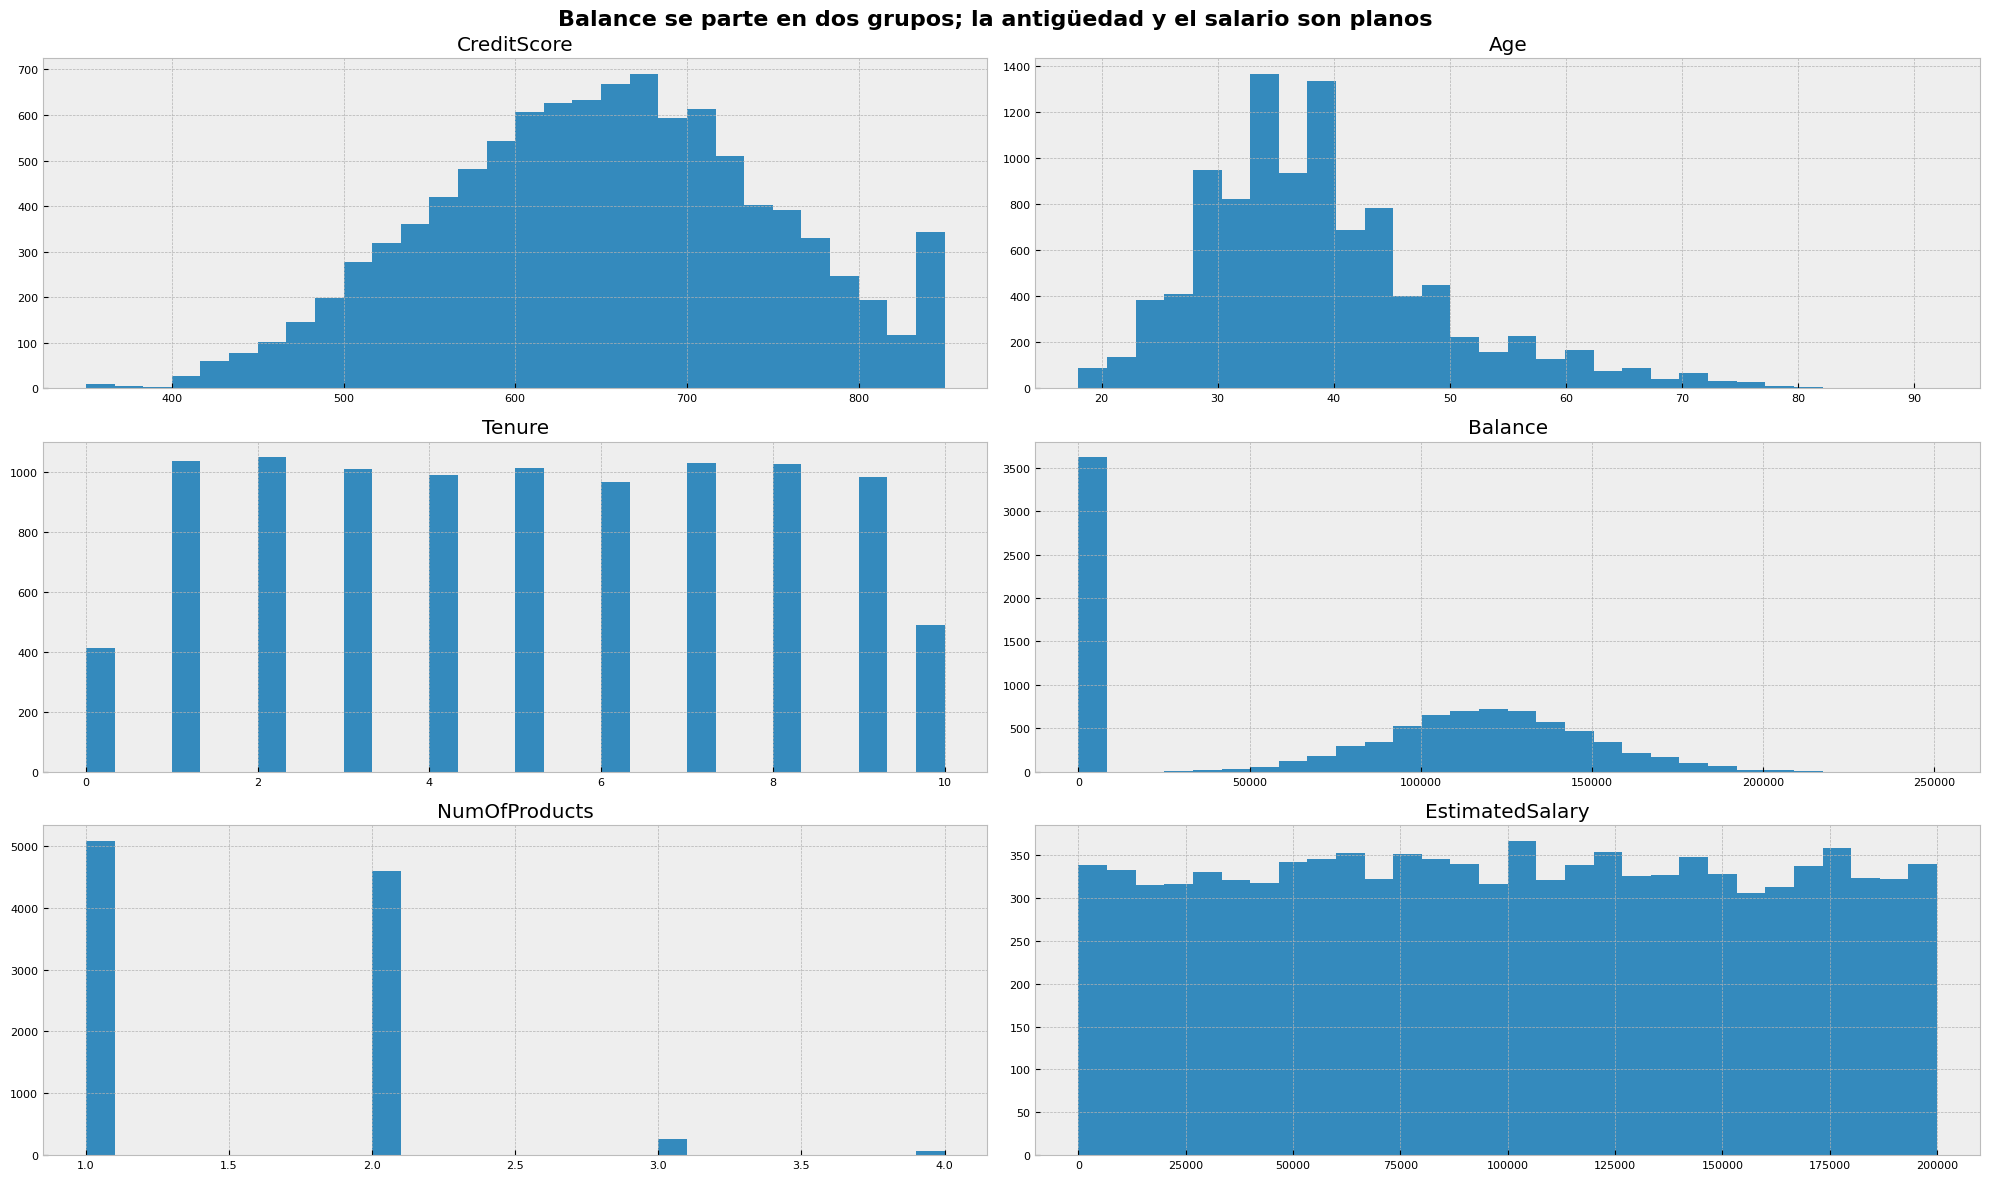

In [51]:
numerical_cols.hist(figsize=(20, 12), bins=30, xlabelsize=8, ylabelsize=8)
plt.suptitle('Balance se parte en dos grupos; la antigüedad y el salario son planos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/histograma_columnas_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

- Age tiende hacia la izquierda: la mayoría de los clientes tiene entre 30 y 40 años, con una
  cola larga de clientes mayores.
- Credit score se ve normal, con un pequeño pico en el máximo (850).
- Balance tiene una gran cantidad de 0 (3.617 clientes, 36,2%), por lo que va a sesgar mi modelo.
  El resto se concentra en torno a ~120.000. Se analiza en la Sección 5.
- Tenure y EstimatedSalary tienen una distribución prácticamente uniforme: todos los valores
  son igual de frecuentes. Una variable así rara vez diferencia a unos clientes de otros, algo
  que se confirma en la Sección 4.7.
- NumOfProducts es discreta (1 a 4), casi todos los clientes tienen 1 o 2 productos.

## 3.2 Variables categóricas y binarias

In [52]:
categorical_cols = df2[df2.columns[(df2.dtypes == 'object') | (df2.dtypes == 'bool')]]
categorical_cols.sample(5, random_state=42)

,Geography,Gender
6252,Germany,Male
4684,France,Male
1731,Spain,Female
4742,Germany,Male
4521,Spain,Female


In [53]:
categorical_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Geography  10000 non-null  object
 1   Gender     10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [54]:
categorical_cols.describe()

,Geography,Gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


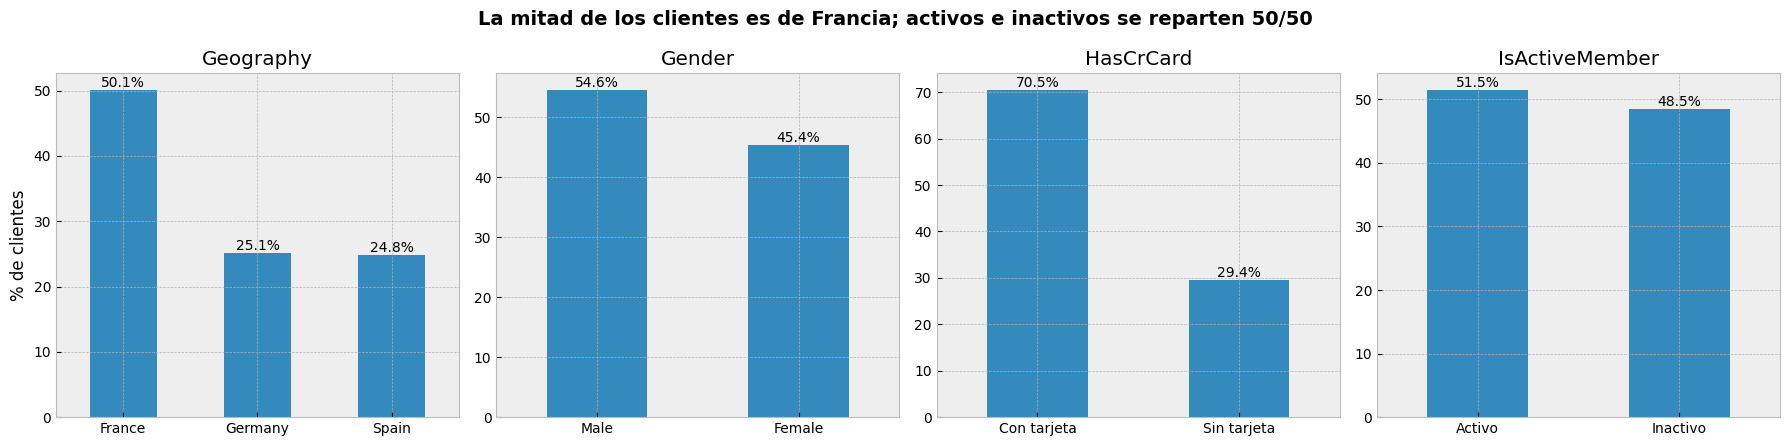

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
etiquetas_binarias = {
    'HasCrCard':      {1: 'Con tarjeta', 0: 'Sin tarjeta'},
    'IsActiveMember': {1: 'Activo', 0: 'Inactivo'},
}
for ax, col in zip(axes, ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']):
    valores = df[col].map(etiquetas_binarias[col]) if col in etiquetas_binarias else df[col]
    (valores.value_counts(normalize=True) * 100).plot(kind='bar', ax=ax, rot=0)
    ax.bar_label(ax.containers[0], fmt='%.1f%%')
    ax.set_title(col)
    ax.set_xlabel('')
axes[0].set_ylabel('% de clientes')
plt.suptitle('La mitad de los clientes es de Francia; activos e inactivos se reparten 50/50', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/distribucion_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

- Geography: la mitad de los clientes es de Francia (50,1%); Alemania (25,1%) y España
  (24,8%) se reparten la otra mitad.
- Gender: 54,6% hombres y 45,4% mujeres.
- HasCrCard: el 70,5% de los clientes tiene tarjeta de crédito.
- IsActiveMember: prácticamente 50/50 entre activos (51,5%) e inactivos.
- Surname tiene 2.932 valores distintos sobre 10.000 clientes: es un identificador personal sin
  valor predictivo y, además, un dato personal, por lo que se excluye del modelado.

## 3.3 Relaciones entre variables

Pregunta de negocio: ¿qué atributos se mueven juntos, y cuáles se relacionan con los dos
targets?

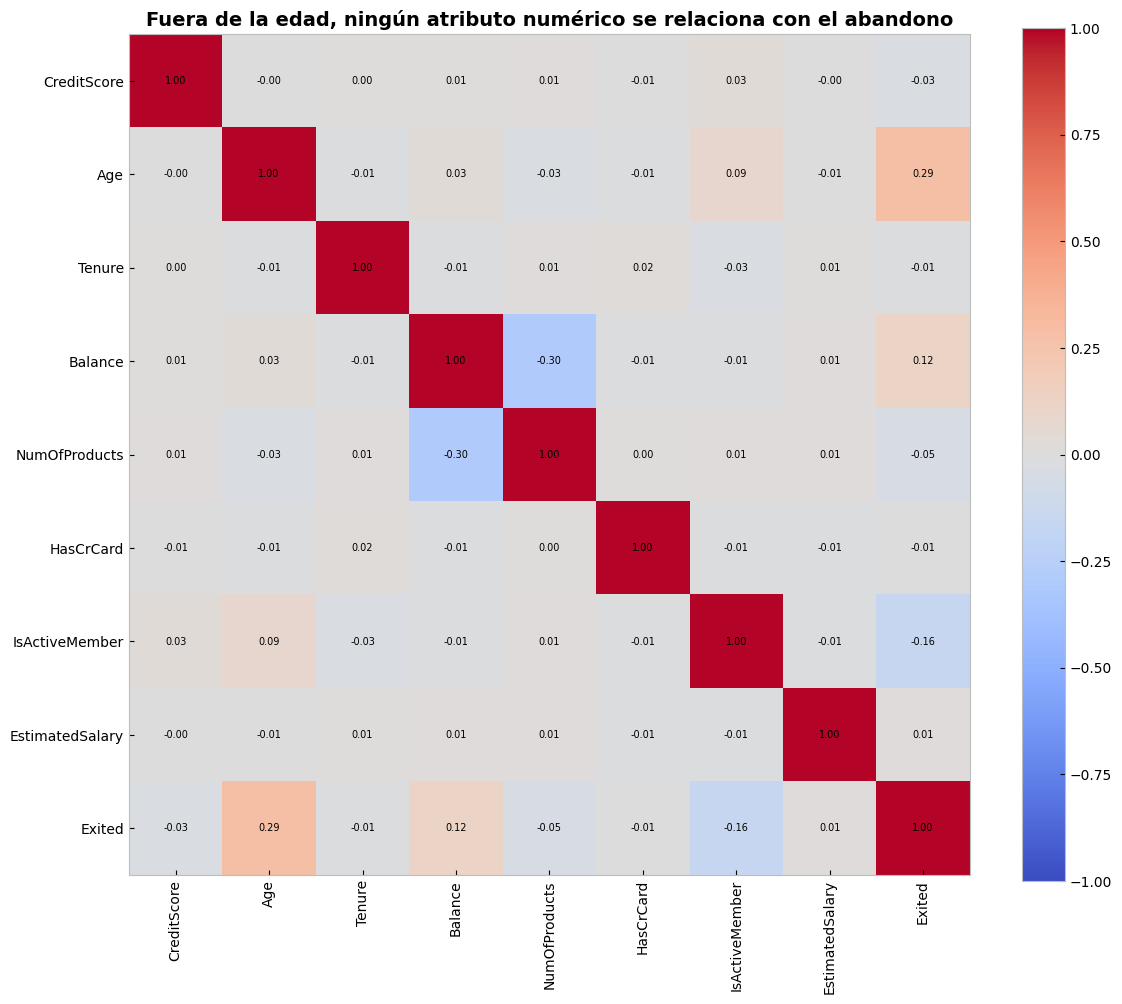

In [56]:
correlacion = df.drop(columns=['CustomerId', 'Surname', 'Geography', 'Gender']).corr()

fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.imshow(correlacion, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlacion.columns)))
ax.set_yticks(range(len(correlacion.columns)))
ax.set_xticklabels(correlacion.columns, rotation=90)
ax.set_yticklabels(correlacion.columns)
ax.grid(False)
fig.colorbar(cax)

for i in range(len(correlacion.columns)):
    for j in range(len(correlacion.columns)):
        ax.text(j, i, f'{correlacion.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

ax.set_title('Fuera de la edad, ningún atributo numérico se relaciona con el abandono', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

- No hay multicolinealidad: la correlación más fuerte entre dos atributos es Balance vs.
  NumOfProducts (-0,30); el resto está prácticamente en 0.
- Con **Exited** la variable más correlacionada es Age (0,29), seguida de IsActiveMember
  (-0,16) y Balance (0,12). CreditScore, Tenure, HasCrCard y EstimatedSalary son
  prácticamente independientes del abandono.
- Esta matriz deja fuera a Geography y Gender, porque son texto y la correlación solo se
  calcula entre números. Además, NumOfProducts se trata aquí como un número (1 a 4), por lo que
  solo se mide si el abandono sube o baja de forma pareja con la cantidad de productos.

Para incluir las categóricas se codifican con *one-hot encoding*: cada categoría pasa a ser una
columna 0/1 (por ejemplo, Geography_Germany vale 1 si el cliente es de Alemania y 0 si no).
NumOfProducts también se codifica, para ver el efecto de cada cantidad de productos por separado.
Se conservan todas las categorías para que la matriz sea más fácil de leer.

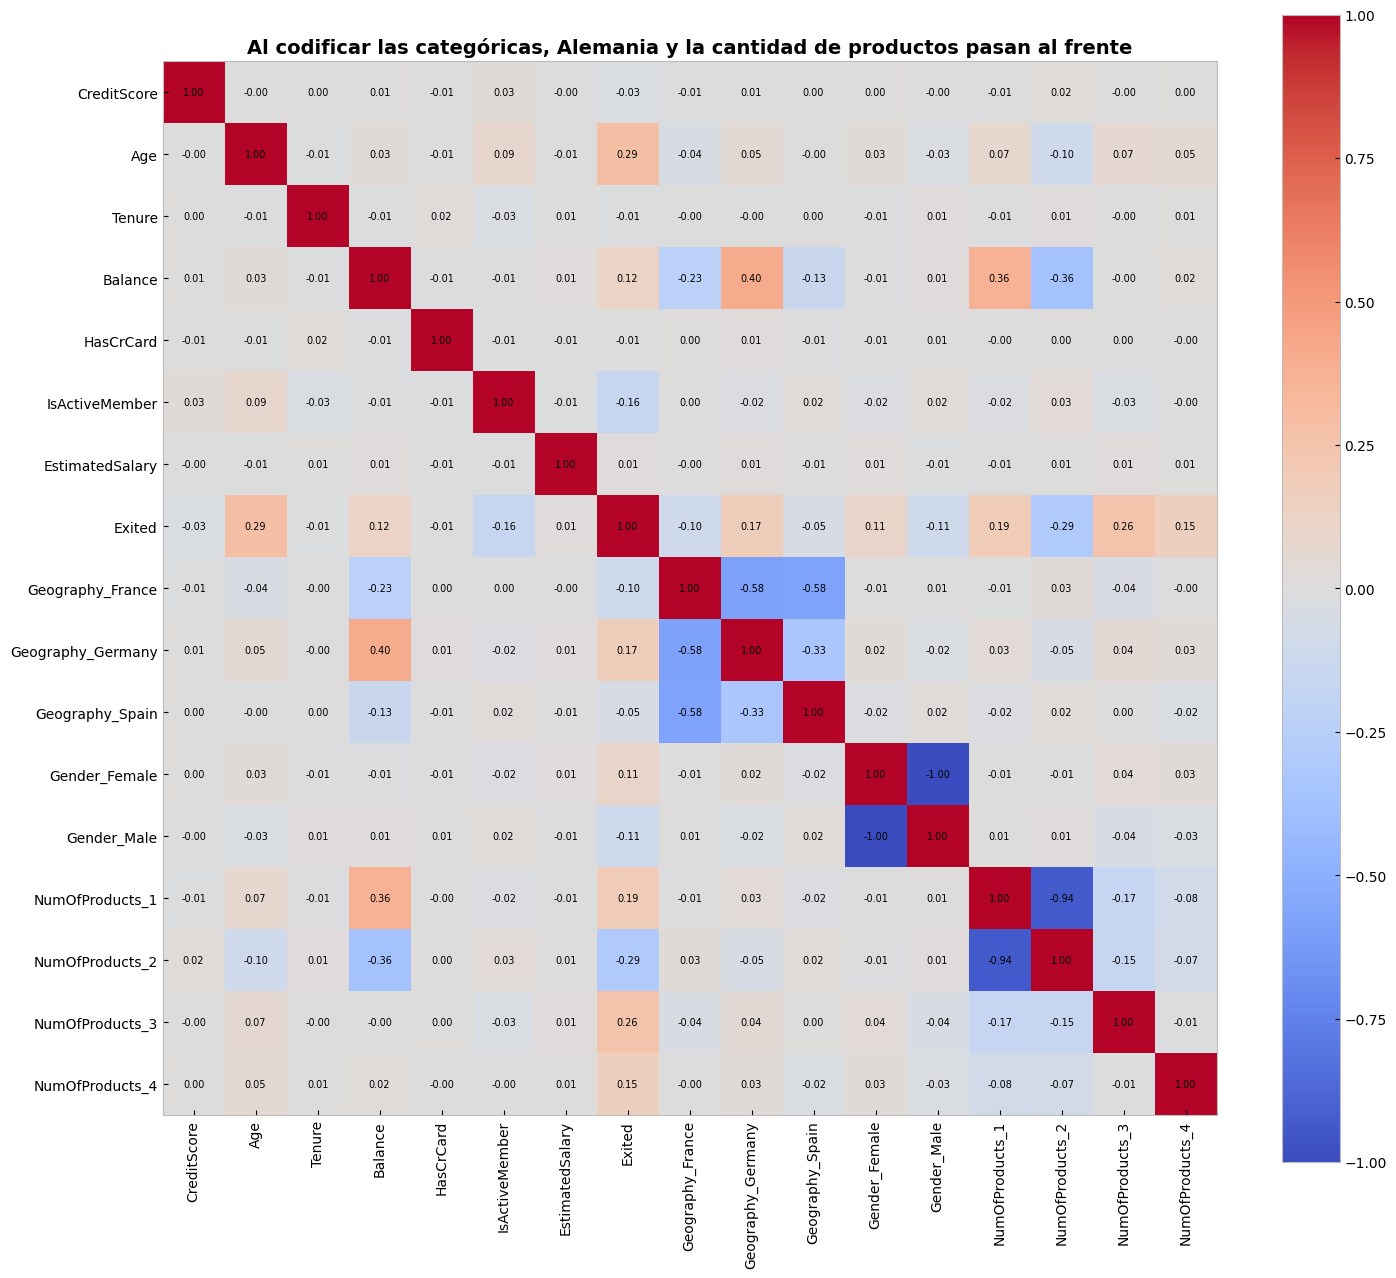

In [57]:
df_codificado = pd.get_dummies(
    df.drop(columns=['CustomerId', 'Surname']),
    columns=['Geography', 'Gender', 'NumOfProducts'], dtype=int
)
correlacion_codificada = df_codificado.corr()

fig, ax = plt.subplots(figsize=(15, 13))
cax = ax.imshow(correlacion_codificada, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlacion_codificada.columns)))
ax.set_yticks(range(len(correlacion_codificada.columns)))
ax.set_xticklabels(correlacion_codificada.columns, rotation=90)
ax.set_yticklabels(correlacion_codificada.columns)
ax.grid(False)
fig.colorbar(cax)

for i in range(len(correlacion_codificada.columns)):
    for j in range(len(correlacion_codificada.columns)):
        ax.text(j, i, f'{correlacion_codificada.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

ax.set_title('Al codificar las categóricas, Alemania y la cantidad de productos pasan al frente', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/matriz_correlacion_codificada.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
# Correlación de cada categoría codificada con los dos targets
columnas_codificadas = [col for col in df_codificado.columns
                        if col.startswith(('Geography_', 'Gender_', 'NumOfProducts_'))]
correlacion_codificada.loc[columnas_codificadas, ['Balance', 'Exited']].round(3)

,Balance,Exited
Geography_France,-0.231,-0.105
Geography_Germany,0.401,0.173
Geography_Spain,-0.135,-0.053
Gender_Female,-0.012,0.107
Gender_Male,0.012,-0.107
NumOfProducts_1,0.360,0.185
NumOfProducts_2,-0.363,-0.292
NumOfProducts_3,-0.003,0.256
NumOfProducts_4,0.021,0.154


Al codificar las categóricas aparecen relaciones que la primera matriz no podía mostrar:

- **Geography_Germany vs. Balance (0,40):** la correlación más fuerte con el saldo de todo el
  dataset. Como se vio en la Sección 2.7, se debe a que ningún cliente alemán tiene saldo 0, por
  lo que probablemente se debe a cómo se armó la muestra.
- **NumOfProducts, separado por categoría:** tener **2 productos** reduce el abandono (-0,29) y
  tener **3** lo aumenta (0,26). Los dos efectos van en sentidos opuestos y al tratarlo como
  número se anulan entre sí (-0,05). Se desarrolla en la Sección 4.2.
- **Gender:** relación moderada con el abandono (mujeres, 0,11) y ninguna con el saldo.
- **Columnas de una misma variable:** se correlacionan negativamente entre sí (por ejemplo,
  Gender_Female vs. Gender_Male = -1), porque un cliente solo pertenece a una categoría: con
  las demás columnas de la variable siempre se puede deducir la que falta. Es esperable, y hay
  que tenerlo en cuenta al preparar los datos para no repetir información.
- La correlación de Pearson solo mide relaciones lineales: la relación de Age con el abandono
  no es lineal y se analiza en la Sección 4.3.

# 4. Hallazgos sobre el abandono (target de clasificación)

Cada sección responde una pregunta de negocio sobre qué clientes abandonan la empresa. La línea
punteada de los gráficos marca el abandono promedio (20,4%).

## 4.1 1 de cada 5 clientes abandonó la empresa
Pregunta de negocio: ¿qué tan frecuente es el abandono?

Exited
Se mantuvo    7963
Abandonó      2037
Name: count, dtype: int64


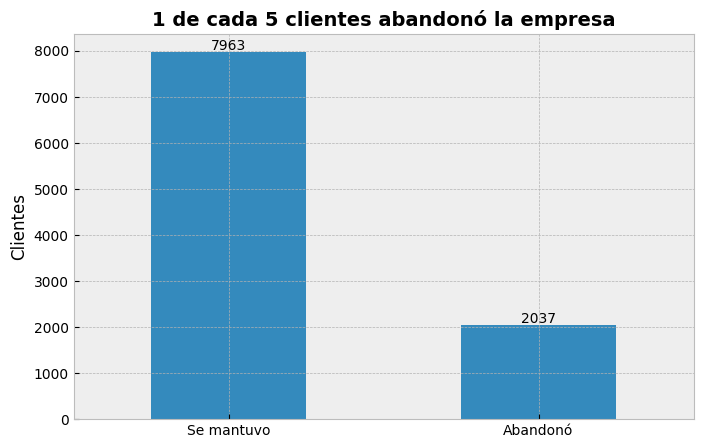

In [59]:
conteo_exited = df['Exited'].map({0: 'Se mantuvo', 1: 'Abandonó'}).value_counts()
print(conteo_exited)

ax = conteo_exited.plot(kind='bar', figsize=(8, 5), rot=0)
ax.bar_label(ax.containers[0])
plt.title('1 de cada 5 clientes abandonó la empresa', fontsize=14, fontweight='bold')
plt.ylabel('Clientes')
plt.xlabel('')
plt.savefig('../images/distribucion_exited.png', dpi=150, bbox_inches='tight')
plt.show()

2.037 de 10.000 clientes abandonaron (20,4%): las clases están **desbalanceadas**. Consecuencias
para el modelado:

- La *accuracy* no sirve como métrica principal: un modelo que prediga siempre "se mantiene"
  acierta el 79,6% sin detectar un solo abandono. Se usarán recall, precisión, F1 y ROC-AUC.
- La partición train/test debe ser **estratificada**, para mantener la misma proporción de
  abandono en ambos conjuntos.

## 4.2 Con 3 o más productos, casi todos los clientes se van
Pregunta de negocio: ¿la cantidad de productos contratados se relaciona con el abandono?

               clientes   tasa
NumOfProducts                 
1                  5084   27.7
2                  4590    7.6
3                   266   82.7
4                    60  100.0


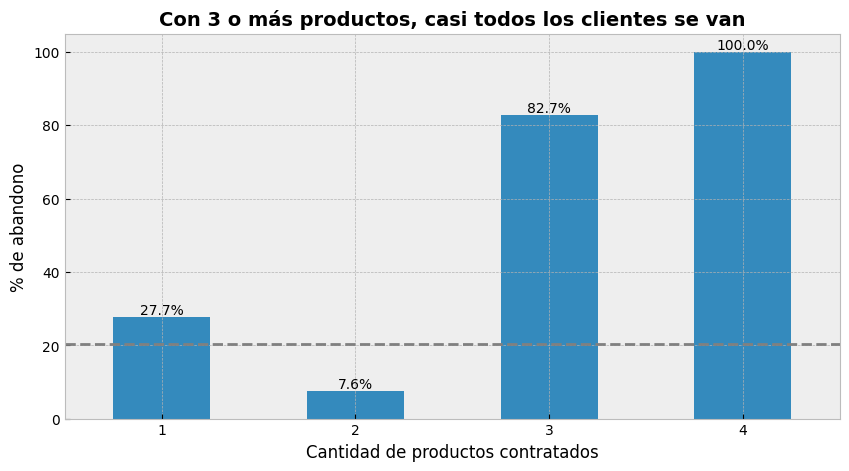

In [60]:
abandono_productos = df.groupby('NumOfProducts')['Exited'].agg(clientes='size', tasa='mean')
abandono_productos['tasa'] *= 100
print(abandono_productos.round(1))

ax = abandono_productos['tasa'].plot(kind='bar', figsize=(10, 5), rot=0)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.axhline(df['Exited'].mean() * 100, color='gray', linestyle='--')
plt.title('Con 3 o más productos, casi todos los clientes se van', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de productos contratados')
plt.ylabel('% de abandono')
plt.savefig('../images/abandono_por_productos.png', dpi=150, bbox_inches='tight')
plt.show()

La relación **no es ordinal**: con 1 producto abandona el 27,7%, con 2 solo el 7,6%, pero con 3
el 82,7% y con 4 el **100%** (60 de 60). Pasar de 1 a 2 productos reduce el abandono a menos de
un tercio, pero pasar a 3 lo multiplica por 11. Por eso la correlación lineal de NumOfProducts
con Exited es casi nula (-0,05) pese a ser el atributo más informativo del dataset.

Para el negocio, los clientes con 3 o 4 productos (326, el 3,3% de la cartera) son un grupo de
riesgo casi seguro. Son pocos, así que la causa conviene investigarla caso a caso (¿productos
contratados en una promoción agresiva? ¿un producto con problemas?).

**Implicancia para la preparación de datos:** NumOfProducts no debería tratarse como un número
que sube o baja de forma pareja, sino como categorías (1, 2, 3 o 4 productos).

## 4.3 El riesgo de abandono es máximo entre los 50 y 60 años
Pregunta de negocio: ¿la edad del cliente se relaciona con el abandono?

       clientes  tasa
Age                  
18-30      1968   7.5
31-40      4451  12.1
41-50      2320  34.0
51-60       797  56.2
61-70       331  31.4
71+         133   8.3


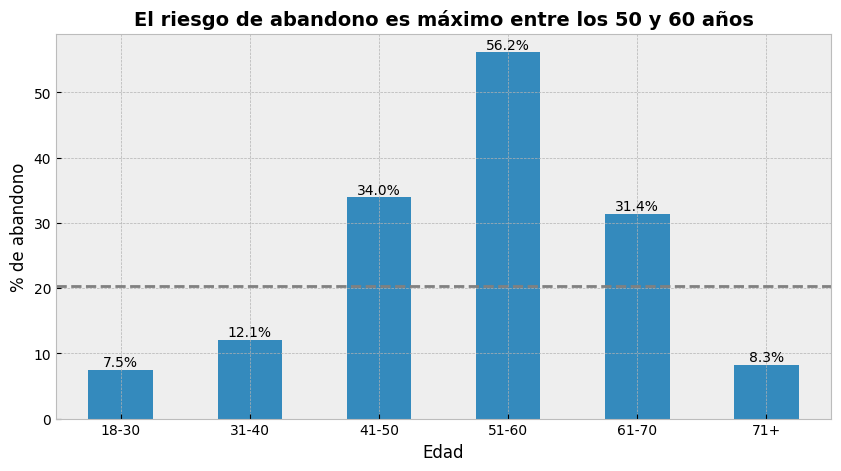

In [61]:
tramos_edad = pd.cut(df['Age'], bins=[17, 30, 40, 50, 60, 70, 100],
                     labels=['18-30', '31-40', '41-50', '51-60', '61-70', '71+'])
abandono_edad = df.groupby(tramos_edad, observed=True)['Exited'].agg(clientes='size', tasa='mean')
abandono_edad['tasa'] *= 100
print(abandono_edad.round(1))

ax = abandono_edad['tasa'].plot(kind='bar', figsize=(10, 5), rot=0)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.axhline(df['Exited'].mean() * 100, color='gray', linestyle='--')
plt.title('El riesgo de abandono es máximo entre los 50 y 60 años', fontsize=14, fontweight='bold')
plt.xlabel('Edad')
plt.ylabel('% de abandono')
plt.savefig('../images/abandono_por_edad.png', dpi=150, bbox_inches='tight')
plt.show()

El abandono sube de 7,5% (18-30 años) a 56,2% (51-60) y vuelve a caer en los mayores: 31,4%
entre 61 y 70, y 8,3% sobre 70. Una relación en forma de U invertida no se captura bien con Age
en bruto (que es lineal), pero sí midiendo la **distancia a la edad de mayor riesgo**. Se busca
cuál es esa edad:

In [62]:
r_bruto = df['Age'].corr(df['Exited'])
print(f'r(Age, Exited) = {r_bruto:+.4f}\n')

for centro in range(40, 62, 2):
    r = (df['Age'] - centro).abs().corr(df['Exited'])
    print(f'r(|Age - {centro}|, Exited) = {r:+.4f}')

r(Age, Exited) = +0.2853

r(|Age - 40|, Exited) = +0.0410
r(|Age - 42|, Exited) = -0.0532
r(|Age - 44|, Exited) = -0.1458
r(|Age - 46|, Exited) = -0.2255
r(|Age - 48|, Exited) = -0.2854
r(|Age - 50|, Exited) = -0.3253
r(|Age - 52|, Exited) = -0.3483
r(|Age - 54|, Exited) = -0.3580
r(|Age - 56|, Exited) = -0.3587
r(|Age - 58|, Exited) = -0.3526
r(|Age - 60|, Exited) = -0.3444


La correlación con la distancia es máxima (en valor absoluto) alrededor de los 54-56 años
(r ≈ -0,36), más fuerte que la edad en bruto (r ≈ 0,29). El signo negativo indica que mientras
más lejos está un cliente de esa edad, menos probable es que abandone.

**Implicancia para la preparación de datos:** además de la edad en bruto, conviene incluir una
medida de qué tan cerca está cada cliente de los ~55 años, que es donde el riesgo es máximo.

## 4.4 Después de los 60, un cliente inactivo abandona 7 veces más que uno activo
Pregunta de negocio: ¿la actividad del cliente cambia el efecto de la edad?

           Inactivo  Activo
Age                        
18-40          13.5     7.9
41-60          51.1    28.2
Más de 60      82.0    11.2 

IsActiveMember     0     1
Age                       
18-40           3198  3221
41-60           1562  1555
Más de 60         89   375


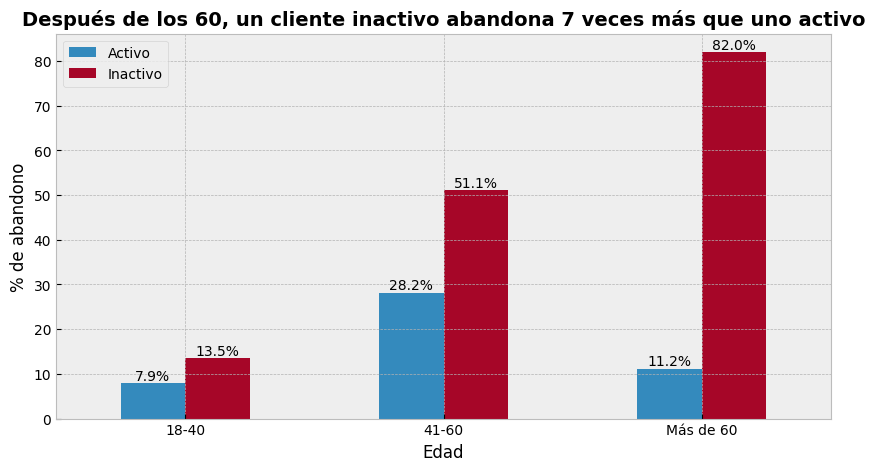

In [63]:
grupos_edad = pd.cut(df['Age'], bins=[17, 40, 60, 100], labels=['18-40', '41-60', 'Más de 60'])
abandono_actividad = df.pivot_table(index=grupos_edad, columns='IsActiveMember', values='Exited',
                                    aggfunc='mean', observed=True) * 100
abandono_actividad.columns = ['Inactivo', 'Activo']
print(abandono_actividad.round(1), '\n')
print(pd.crosstab(grupos_edad, df['IsActiveMember']))

ax = abandono_actividad[['Activo', 'Inactivo']].plot(kind='bar', figsize=(10, 5), rot=0)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%')
plt.title('Después de los 60, un cliente inactivo abandona 7 veces más que uno activo', fontsize=14, fontweight='bold')
plt.xlabel('Edad')
plt.ylabel('% de abandono')
plt.savefig('../images/abandono_edad_actividad.png', dpi=150, bbox_inches='tight')
plt.show()

La edad y la actividad **interactúan**: entre los 18 y 40 años ser inactivo casi no importa
(13,5% vs. 7,9%), pero entre los mayores de 60 es la diferencia entre quedarse y casi seguro
irse (82,0% de los inactivos vs. 11,2% de los activos). Es una señal accionable: un cliente
mayor que deja de usar sus productos es una alerta temprana de abandono. El grupo es chico (89
clientes inactivos mayores de 60), así que la cifra exacta es menos precisa que la tendencia.

Este tipo de interacción la captan automáticamente los modelos basados en árboles de decisión,
por lo que conviene incluirlos entre los modelos a comparar.

## 4.5 Alemania abandona más dentro de cada grupo de productos, actividad y edad
Pregunta de negocio: ¿el país del cliente se relaciona con el abandono?

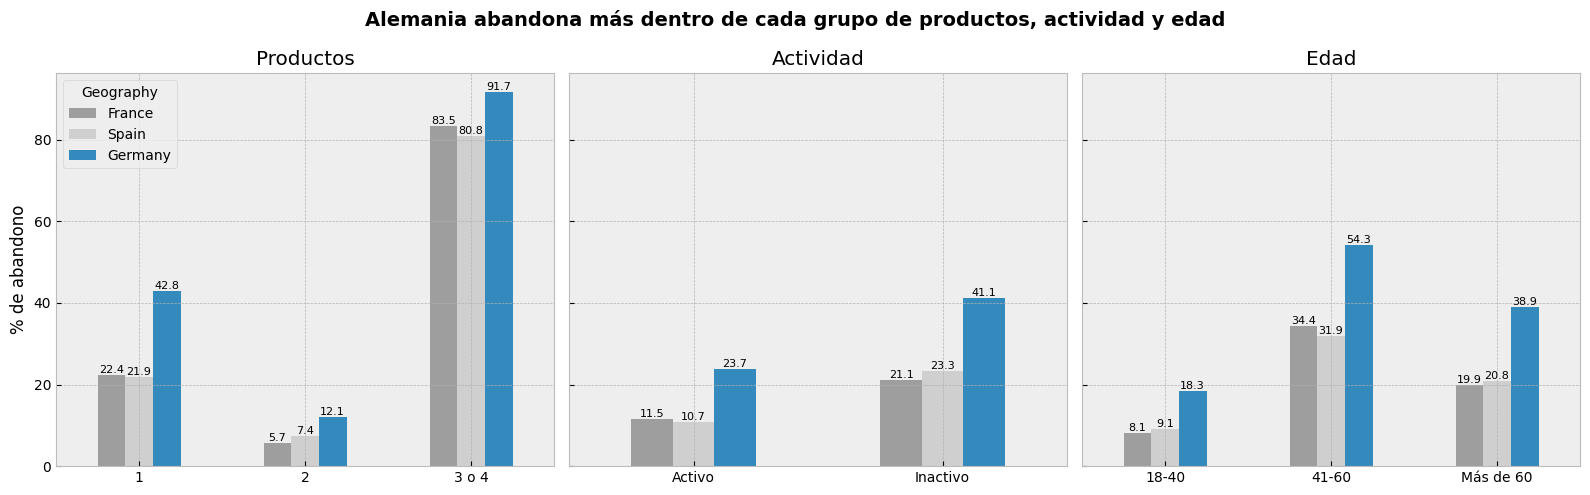

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, nombre in zip(axes, ['Productos', 'Actividad', 'Edad']):
    tabla = df.groupby([variables_control[nombre], 'Geography'], observed=True)['Exited'].mean().unstack() * 100
    tabla = tabla[['France', 'Spain', 'Germany']]
    tabla.plot(kind='bar', ax=ax, rot=0, color=['#9e9e9e', '#cfcfcf', '#348abd'], legend=(nombre == 'Productos'))
    for contenedor in ax.containers:
        ax.bar_label(contenedor, fmt='%.1f', fontsize=8)
    ax.set_title(nombre)
    ax.set_xlabel('')
axes[0].set_ylabel('% de abandono')
plt.suptitle('Alemania abandona más dentro de cada grupo de productos, actividad y edad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/abandono_por_pais.png', dpi=150, bbox_inches='tight')
plt.show()

En total, Alemania abandona el 32,4%, contra 16,2% de Francia y 16,7% de España. Al comparar
clientes parecidos (misma cantidad de productos, actividad o edad), Alemania abandona más en
todos los grupos, así que la diferencia no la explican esas variables. Pero el tamaño de la diferencia
cambia:

- Entre 1,6 y 2,2 veces más en la mayoría de los grupos (por ejemplo, 18,3% vs. 8,4% entre los
  18 y 40 años, y 54,3% vs. 33,5% entre los 41 y 60).
- Solo 1,1 veces más con 3 o 4 productos (91,7% vs. 82,5%), porque ahí casi todos los clientes
  abandonan, sean del país que sean.

Cada panel separa a los clientes según una variable distinta, y dentro de cada grupo compara a
los tres países. Los paneles no se comparan entre sí: son tres formas de verificar lo mismo.

Francia y España se comportan prácticamente igual en todos los grupos (sus barras grises casi
coinciden, con diferencias de 0,5 a 2,5 puntos), mientras que Alemania queda entre 8 y 20 puntos
por encima. Por eso, en la tabla de la Sección 2.8 se agrupan como "Francia/España" para
calcular cuántas veces más abandona Alemania. Si la diferencia es un efecto real o del muestreo (Sección 2.7) no se puede saber con
estos datos.

El país es la única variable categórica, junto con NumOfProducts, que cambia el abandono de
forma marcada. Francia y España se comportan igual, por lo que para el negocio la distinción
relevante es "Alemania vs. el resto".

## 4.6 Las mujeres abandonan 1,5 veces más que los hombres
Pregunta de negocio: ¿el género se relaciona con el abandono?

Gender
Hombres    16.5
Mujeres    25.1
Name: Exited, dtype: float64


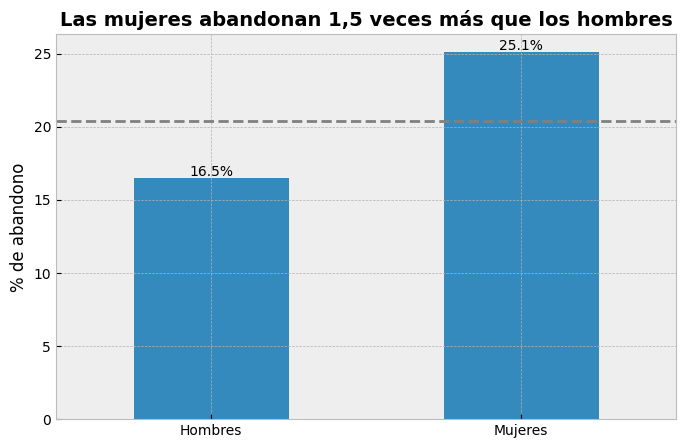

In [65]:
abandono_genero = df.groupby(df['Gender'].map({'Female': 'Mujeres', 'Male': 'Hombres'}))['Exited'].mean() * 100
print(abandono_genero.round(1))

ax = abandono_genero.plot(kind='bar', figsize=(8, 5), rot=0)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.axhline(df['Exited'].mean() * 100, color='gray', linestyle='--')
plt.title('Las mujeres abandonan 1,5 veces más que los hombres', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('% de abandono')
plt.savefig('../images/abandono_por_genero.png', dpi=150, bbox_inches='tight')
plt.show()

25,1% de abandono en mujeres contra 16,5% en hombres. La diferencia es clara, pero usar el
género para decidir a quién ofrecer retención puede significar tratar distinto a los clientes
por su género. Se incluye como predictor, pero su aporte se mide en el modelamiento para decidir si vale la
pena conservarlo.

## 4.7 Antigüedad, salario, puntaje crediticio y tarjeta casi no cambian el abandono
Pregunta de negocio: ¿qué atributos **no** sirven para anticipar el abandono?

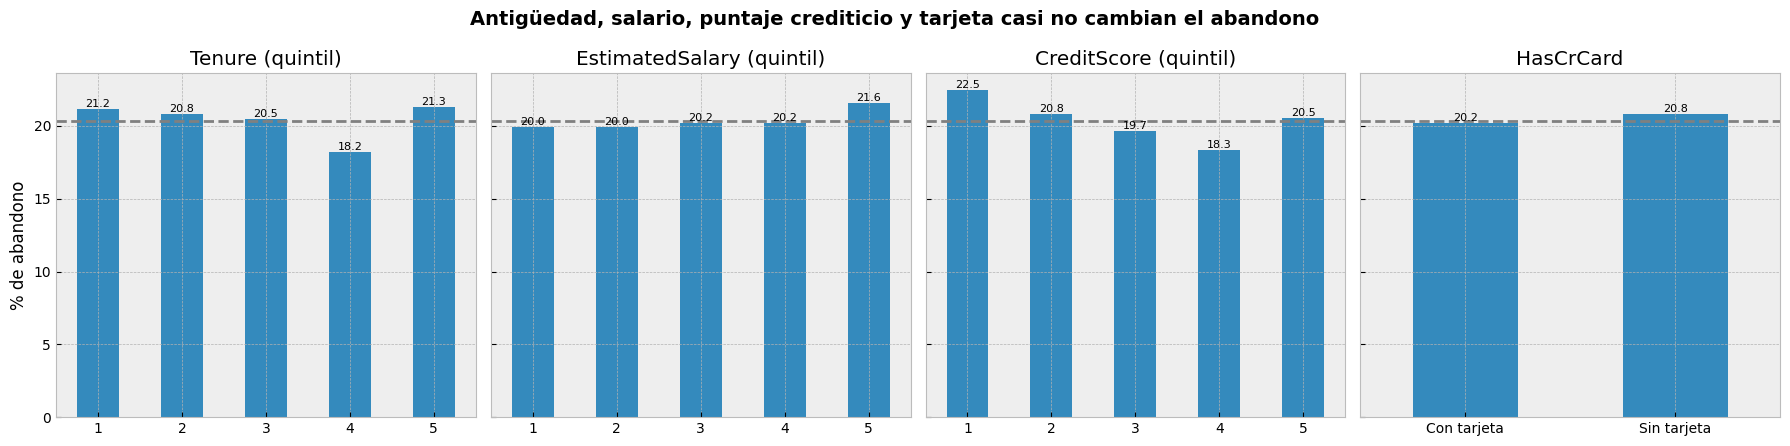

In [66]:
variables_sin_efecto = {
    'Tenure (quintil)':          pd.qcut(df['Tenure'], 5, labels=False, duplicates='drop') + 1,
    'EstimatedSalary (quintil)': pd.qcut(df['EstimatedSalary'], 5, labels=False) + 1,
    'CreditScore (quintil)':     pd.qcut(df['CreditScore'], 5, labels=False) + 1,
    'HasCrCard':                 df['HasCrCard'].map({0: 'Sin tarjeta', 1: 'Con tarjeta'}),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, (nombre, grupos) in zip(axes, variables_sin_efecto.items()):
    (df.groupby(grupos)['Exited'].mean() * 100).plot(kind='bar', ax=ax, rot=0)
    ax.bar_label(ax.containers[0], fmt='%.1f', fontsize=8)
    ax.axhline(df['Exited'].mean() * 100, color='gray', linestyle='--')
    ax.set_title(nombre)
    ax.set_xlabel('')
axes[0].set_ylabel('% de abandono')
plt.suptitle('Antigüedad, salario, puntaje crediticio y tarjeta casi no cambian el abandono', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/abandono_variables_sin_efecto.png', dpi=150, bbox_inches='tight')
plt.show()

En todos los grupos (quintiles de 1 = valores más bajos a 5 = más altos, y sin/con tarjeta) el
abandono se mueve entre 18% y 23%, alrededor del promedio. Que estas variables no importen
también es un hallazgo: descarta hipótesis intuitivas (que los clientes nuevos o los de menores
ingresos se vayan más) y confirma lo que ya mostraba la matriz de correlación. No se espera que
aporten a los modelos.

Un matiz de CreditScore: el quintil más bajo agrupa puntajes hasta ~566. Si se mira solo el
extremo (puntajes de 350 a 450, 189 clientes), el abandono sube a 32%, pero es un grupo muy
chico para cambiar el panorama general.

# 5. Hallazgos sobre el saldo (target de regresión)

## 5.1 Balance es el único atributo continuo que se puede predecir
Pregunta de negocio: ¿qué variable continua conviene usar como target de regresión?

Un atributo solo se puede predecir si está relacionado con alguno de los otros. Se calcula,
para cada candidato, su correlación absoluta más alta con el resto de las variables, excluyendo
Exited. Para incluir las categóricas se usa la misma codificación temporal de la Sección 3.3
(una columna 0/1 por categoría, solo para poder calcular la correlación); en la tabla, la
variable más relacionada se muestra como "variable = categoría", por ejemplo
"NumOfProducts = 2" significa "tener 2 productos". Como la relación de Balance con Alemania probablemente
se debe a cómo se armó la muestra (Sección 2.7), se repite el cálculo **sin Geography** y **solo con
clientes de Francia y España**, para asegurar que la elección no dependa de ese patrón.

In [67]:
candidatas = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']


def correlacion_maxima(datos, categoricas):
    atributos = pd.get_dummies(datos.drop(columns=['CustomerId', 'Surname', 'Exited']),
                               columns=categoricas, dtype=int)
    corr_abs = atributos.corr().abs()
    np.fill_diagonal(corr_abs.values, 0)
    variable_mas_relacionada = corr_abs.loc[candidatas].idxmax(axis=1)
    for categorica in categoricas:
        variable_mas_relacionada = variable_mas_relacionada.str.replace(f'{categorica}_', f'{categorica} = ')
    return corr_abs.loc[candidatas].max(axis=1), variable_mas_relacionada


escenarios_target = {
    'todos':                  (df, ['Geography', 'Gender', 'NumOfProducts']),
    'todos_sin_Geography':    (df.drop(columns='Geography'), ['Gender', 'NumOfProducts']),
    'solo_Francia_Espana':    (df[df['Geography'] != 'Germany'].drop(columns='Geography'), ['Gender', 'NumOfProducts']),
}
tabla_target = {}
for nombre, (datos, categoricas) in escenarios_target.items():
    maximo, variable = correlacion_maxima(datos, categoricas)
    tabla_target[f'{nombre}'] = maximo
    tabla_target[f'{nombre} (con)'] = variable

pd.DataFrame(tabla_target).sort_values('todos', ascending=False).round(3)

,todos,todos (con),todos_sin_Geography,todos_sin_Geography (con),solo_Francia_Espana,solo_Francia_Espana (con)
Balance,0.401,Geography = Germany,0.363,NumOfProducts = 2,0.448,NumOfProducts = 1
Age,0.103,NumOfProducts = 2,0.103,NumOfProducts = 2,0.108,IsActiveMember
Tenure,0.028,IsActiveMember,0.028,IsActiveMember,0.019,IsActiveMember
CreditScore,0.026,IsActiveMember,0.026,IsActiveMember,0.024,IsActiveMember
EstimatedSalary,0.013,Balance,0.013,Balance,0.018,HasCrCard


- Con todos los datos, Balance llega a 0,40 con ser de Alemania, una relación sospechosa
  (Sección 2.7).
- **Sin Geography o solo con Francia y España, Balance sigue siendo por lejos el mejor
  candidato** (0,36 y 0,45), gracias a su relación con la cantidad de productos (tener 1 o 2
  productos), que no depende del país.
- Age apenas llega a 0,10, y CreditScore, Tenure y EstimatedSalary no superan 0,03 con
  ninguna variable: ningún modelo podría predecirlos mejor que su promedio.

**Balance es el candidato más adecuado como target de regresión por su relación con la cantidad
de productos**, no por la de Alemania. Hay que tener en cuenta que la relación con Alemania puede
hacer que una regresión sobre Balance parezca mejor de lo que es.

## 5.2 Un tercio de los clientes tiene saldo exactamente 0
Pregunta de negocio: ¿cómo se distribuye el saldo de los clientes?

Clientes con Balance = 0: 3617 (36.17%)

Balance de los clientes con saldo > 0:
count      6383.00
mean     119827.49
std       30095.06
min        3768.69
25%      100181.98
50%      119839.69
75%      139512.29
max      250898.09
Name: Balance, dtype: float64


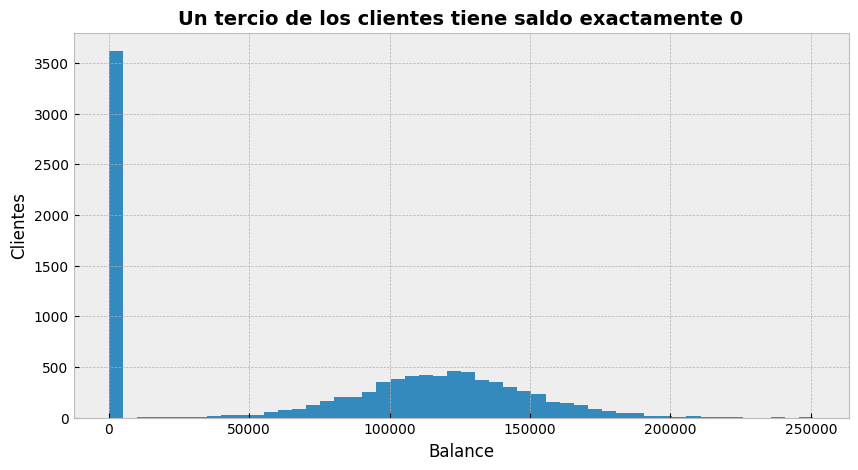

In [68]:
saldo_cero = (df['Balance'] == 0).sum()
print(f"Clientes con Balance = 0: {saldo_cero} ({saldo_cero / len(df) * 100:.2f}%)")
print('\nBalance de los clientes con saldo > 0:')
print(df.loc[df['Balance'] > 0, 'Balance'].describe().round(2))

df['Balance'].hist(bins=50, figsize=(10, 5))
plt.title('Un tercio de los clientes tiene saldo exactamente 0', fontsize=14, fontweight='bold')
plt.xlabel('Balance')
plt.ylabel('Clientes')
plt.savefig('../images/distribucion_balance.png', dpi=150, bbox_inches='tight')
plt.show()

3.617 clientes (36,2%) tienen Balance = 0; el resto se distribuye de forma aproximadamente normal
en torno a ~120.000. Balance tiene una distribución **inflada en cero**: un modelo de regresión
que ajuste una sola curva a ambos grupos va a tener un error alto con los clientes de saldo 0,
salvo que alguna variable permita distinguirlos (Sección 5.3).

## 5.3 Con 2 productos, más de la mitad de los clientes no tiene saldo
Pregunta de negocio: ¿qué distingue a los clientes con saldo 0?

               clientes  balance_medio  pct_saldo_cero
NumOfProducts                                         
1                  5084        98551.9            17.8
2                  4590        51879.1            56.6
3                   266        75458.3            36.8
4                    60        93733.1            23.3


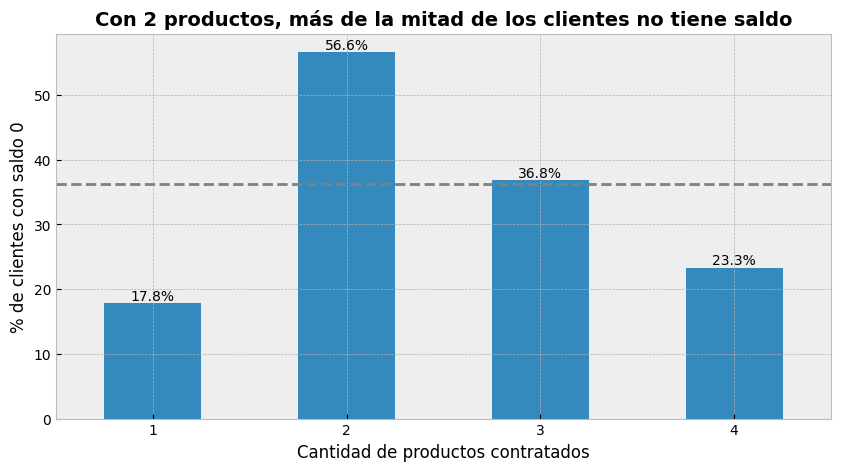

In [69]:
saldo_productos = df.groupby('NumOfProducts')['Balance'].agg(
    clientes='size', balance_medio='mean', pct_saldo_cero=lambda s: (s == 0).mean() * 100
)
print(saldo_productos.round(1))

ax = saldo_productos['pct_saldo_cero'].plot(kind='bar', figsize=(10, 5), rot=0)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.axhline((df['Balance'] == 0).mean() * 100, color='gray', linestyle='--')
plt.title('Con 2 productos, más de la mitad de los clientes no tiene saldo', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de productos contratados')
plt.ylabel('% de clientes con saldo 0')
plt.savefig('../images/saldo_cero_por_productos.png', dpi=150, bbox_inches='tight')
plt.show()

Con 2 productos, el 56,6% de los clientes tiene saldo 0, contra el 17,8% de los que tienen 1
producto (la línea punteada marca el promedio, 36,2%). Es la señal más sólida para predecir el
saldo, porque no depende del país: en Francia y España la diferencia es incluso mayor (73% vs.
24%).

Fuera de la cantidad de productos (y del patrón sospechoso de Alemania), Balance no se relaciona
con ningún otro atributo. Esto fija una expectativa realista para el modelo de regresión:
estimará el saldo esperado de un segmento de clientes, no el saldo individual.

## 5.4 Los clientes con saldo abandonan más
Pregunta de negocio: ¿el saldo se relaciona con el abandono?

In [70]:
grupo_saldo = np.where(df['Balance'] > 0, 'Saldo > 0', 'Saldo = 0')
df.groupby(grupo_saldo)['Exited'].agg(clientes='size', tasa_abandono='mean').round(3)

,clientes,tasa_abandono
Saldo = 0,3617,0.138
Saldo > 0,6383,0.241


Los clientes con saldo > 0 abandonan el 24,1% de las veces, contra el 13,8% de los que tienen
saldo 0: justamente los clientes que más valen para la empresa son los que más se van.

**Implicancia para la preparación de datos:** tener o no tener saldo es informativo para el
abandono. Como Balance ya separa a los clientes con saldo 0 del resto, habrá que revisar si una
variable aparte ("tiene saldo sí/no") agrega información o repite la que ya está en Balance. En
el modelo de regresión no se puede usar nada que se calcule a partir del saldo, porque es el
propio target.

# 6. Resumen de hallazgos

**Sobre el abandono (Exited):**

1. **1 de cada 5 clientes abandonó** (20,4%): clases desbalanceadas, se evalúa con recall, F1 y
   ROC-AUC y se estratifica la partición.
2. **La cantidad de productos es la señal más fuerte**: con 2 productos abandona el 7,6%, con 3
   el 82,7% y con 4 el 100%. La relación no es ordinal.
3. **El riesgo es máximo entre los 50 y 60 años** (56,2%) y cae en los mayores, una U invertida.
4. **La inactividad pesa más con la edad**: sobre los 60, un inactivo abandona 7 veces más que
   un activo (82,0% vs. 11,2%).
5. **Alemania abandona más dentro de cada grupo de productos, actividad y edad** (32,4% vs.
   ~16,5% en total), aun comparando
   clientes parecidos: entre 1,6 y 2,2 veces más, salvo con 3 o 4 productos (1,1 veces), donde
   casi todos abandonan. Su causa no se puede determinar con estos datos.
6. **Las mujeres abandonan 1,5 veces más** que los hombres (25,1% vs. 16,5%).
7. **Antigüedad, salario, puntaje crediticio y tarjeta casi no importan**: todos se mueven
   entre 18% y 23% de abandono.

**Sobre el saldo (Balance):**

8. **Un tercio de los clientes tiene saldo 0** (36,2%): distribución inflada en cero.
9. **Con 2 productos, más de la mitad no tiene saldo** (56,6% vs. 17,8% con 1 producto): es la
   señal sólida para predecir el saldo.
10. **Ningún cliente alemán tiene saldo 0**, aunque entre los clientes con saldo el promedio es
    igual en los tres países: probable sesgo de selección del dataset, que inflará las métricas
    del modelo de regresión.

## Implicancias para la preparación de datos

Lo que estos hallazgos piden a la siguiente etapa, [`preprocesamiento.ipynb`](preprocesamiento.ipynb),
donde se decide cómo implementarlo:

| Hallazgo | Implicancia |
|---|---|
| CustomerId y Surname son identificadores (Sección 2.9) | Excluirlos del modelado. |
| El abandono sube y baja con la cantidad de productos (Sección 4.2) | Tratar NumOfProducts como categórica. |
| Los atípicos de Age son reales e informativos (Secciones 2.6 y 4.3) | No recortarlos. |
| El abandono tiene forma de U invertida con la edad, con máximo ~55 años (Sección 4.3) | Representar la edad de forma que capture esa forma, no solo como número en bruto. |
| Los clientes con saldo abandonan más (Sección 5.4) | Evaluar si "tiene saldo" aporta algo que Balance no tenga ya. |
| Las clases están desbalanceadas (Sección 4.1) | Estratificar la partición entre entrenamiento y prueba. |
| Balance es la única variable continua con relaciones que no dependen del país (Sección 5.1) | Usarla como target de regresión. |
| Exited ocurre después del saldo observado | No usarla como feature del modelo de regresión. |
| El patrón de saldo de Alemania probablemente se debe a cómo se armó la muestra (Secciones 2.7 y 2.8) | Medir en el modelamiento cuánto dependen los resultados de ese patrón. |